**Simple_Classification_Model**

# Customer Churn Prediction using Logistic Regression

## Simple Classification Model

**Internship:** CodeOrbit Tech  
**Role:** Machine Learning Intern  
**Project:** Simple Classification Model  
**Dataset:** Telco Customer Churn

### Objective
To build a simple classification model that predicts whether a customer will churn (leave/cancel the service) or stay.

### Model Used
Logistic Regression

## 1. Dataset

The Telco Customer Churn dataset contains customer information from a telecommunications service.

Each row represents one customer. The target variable is **Churn**, which indicates whether the customer left/cancelled the service.

- `No` → Customer stayed
- `Yes` → Customer churned

### Data Preprocessing

The following preprocessing steps were performed:

1. Removed the `customerID` column because it is only an identifier.
2. Converted `TotalCharges` from text to numeric format.
3. Filled the missing `TotalCharges` values using the median.
4. Converted the `Churn` target into numerical values:
   - `No = 0`
   - `Yes = 1`
5. Applied one-hot encoding to categorical features.

## 2. Train-Test Split

The dataset was divided into two parts:

- **80% Training Data** – used to train the model.
- **20% Testing Data** – used to evaluate the model on unseen data.

The data was split using `train_test_split()` with a `random_state` of 42.

## 3. Classification Model

A **Logistic Regression** model was selected for this classification task.

The model was trained using the training data and then used to predict whether customers in the test dataset would:

- **Stay**
- **Churn (leave/cancel the service)**

## 4. Model Evaluation

The trained Logistic Regression model was evaluated using three metrics required for the classification task:

- **Accuracy** – measures the overall percentage of correct predictions.
- **Precision** – measures how many of the customers predicted as churned actually churned.
- **Recall** – measures how many of the customers who actually churned were correctly identified by the model.

### Evaluation Results

- **Accuracy:** 82.11%
- **Precision:** 68.50%
- **Recall:** 60.05%

## 5. Results

The Logistic Regression model achieved an overall accuracy of **82.11%**.

For the **Churned** class:
- Precision: **68.50%**
- Recall: **60.05%**
- F1-score: **64%**

The model performed better at identifying customers who stayed than customers who churned.

## 6. Conclusion

A Logistic Regression classification model was successfully built to predict customer churn.

The model achieved **82.11% accuracy** on the test dataset. The results show that the model can identify customer churn to a reasonable extent, although there is scope for improving recall and identifying more customers who are likely to leave the service.

## 7. Future Scope

The model could be improved in the future by:

- Trying other classification algorithms such as Decision Tree or Random Forest.
- Performing feature selection.
- Tuning model parameters.
- Using additional customer-related features.

In [27]:
import pandas as pd

url = "https://raw.githubusercontent.com/SohelRaja/Customer-Churn-Analysis/master/Datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
df.shape

(7043, 21)

In [29]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [31]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [32]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [33]:
df_encoded = pd.get_dummies(
    df.drop('customerID', axis=1),
    drop_first=True
)

df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,1,29.85,0,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,0,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,1,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,45,42.30,0,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,1,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [34]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 6559)
y shape: (7043,)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 6559)
Testing data: (1409, 6559)


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))

Accuracy : 0.8211
Precision: 0.685
Recall   : 0.6005


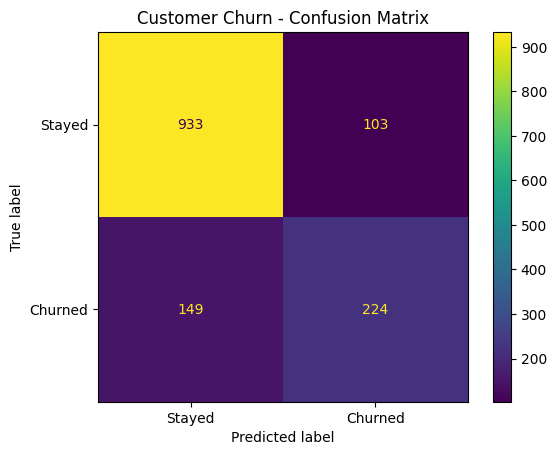

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed', 'Churned']
)

disp.plot()
plt.title("Customer Churn - Confusion Matrix")
plt.show()

In [38]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Stayed', 'Churned']
))

              precision    recall  f1-score   support

      Stayed       0.86      0.90      0.88      1036
     Churned       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [39]:
print("Original columns:", df.shape[1])
print("Encoded columns:", df_encoded.shape[1])
print("Features used:", X.shape[1])

Original columns: 21
Encoded columns: 6560
Features used: 6559


In [40]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df['TotalCharges'].dtype)
print("Missing values:", df['TotalCharges'].isnull().sum())

float64
Missing values: 11


In [41]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("Missing TotalCharges:", df['TotalCharges'].isnull().sum())

Missing TotalCharges: 0


In [42]:
df_encoded = pd.get_dummies(
    df.drop('customerID', axis=1),
    drop_first=True
)

print("Encoded columns:", df_encoded.shape[1])
print(df_encoded.head())

Encoded columns: 31
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...          

In [43]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 30)
y shape: (7043,)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 30)
Testing data: (1409, 30)


In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [46]:
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Final Accuracy :", round(accuracy, 4))
print("Final Precision:", round(precision, 4))
print("Final Recall   :", round(recall, 4))

Final Accuracy : 0.8211
Final Precision: 0.685
Final Recall   : 0.6005


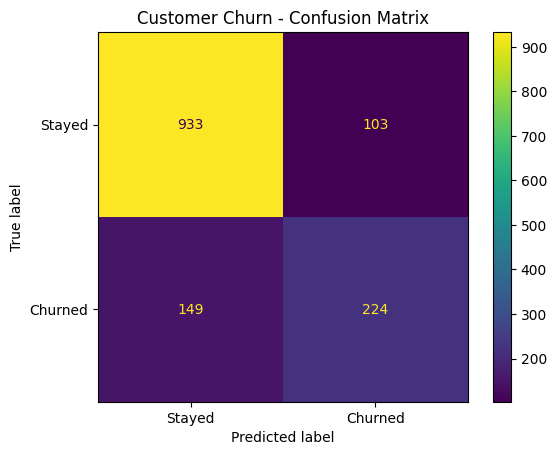

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed', 'Churned']
)

disp.plot()
plt.title("Customer Churn - Confusion Matrix")
plt.show()

In [49]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=['Stayed', 'Churned']
))

              precision    recall  f1-score   support

      Stayed       0.86      0.90      0.88      1036
     Churned       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [50]:
print("===== PROJECT 2 FINAL RESULTS =====")
print("Project: Customer Churn Prediction")
print("Model: Logistic Regression")
print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))
print("Features Used:", X.shape[1])
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")

===== PROJECT 2 FINAL RESULTS =====
Project: Customer Churn Prediction
Model: Logistic Regression
Training Records: 5634
Testing Records: 1409
Features Used: 30
Accuracy: 82.11 %
Precision: 68.5 %
Recall: 60.05 %
